In [1]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt
import os
from ot.lp import wasserstein_1d as wd

plt.style.use("ggplot")

In [2]:
os.getcwd()

'/home/verano13/TransportVsMcmcExperiments_fix/tanh'

In [3]:
budget = 4 ** 8
conditioning_list = [4 ** i for i in range(9)]

wds_nn = np.empty((10, len(conditioning_list)))
wds_ker = np.empty((10, len(conditioning_list)))
wds_sde = np.empty((10, len(conditioning_list)))
wds_mcmc = np.empty((10, len(conditioning_list)))
wds_nn_std = np.empty((10, len(conditioning_list)))
wds_ker_std = np.empty((10, len(conditioning_list)))
wds_sde_std = np.empty((10, len(conditioning_list)))
wds_mcmc_std = np.empty((10, len(conditioning_list)))
for i in range(1,10):
    output_root = "budget_results"
    output_dir = os.path.join(output_root, f"ode_{i}")
    wd_nn_array = np.load(os.path.join(output_dir, "wd_nn_array_mean.npy"))
    # wd_ker_array = np.load(os.path.join(output_dir, "wd_ker_array_mean.npy"))
    # wd_sde_array = np.load(os.path.join(output_dir, "wd_nn_sde_array_mean.npy"))
    wd_mcmc_array = np.load(os.path.join(output_root, f"wd_mcmc_array_mean_{i}.npy"))
    wd_nn_std = np.load(os.path.join(output_dir, "wd_nn_array_std.npy"))
    # wd_ker_std = np.load(os.path.join(output_dir, "wd_ker_array_std.npy"))
    # wd_sde_std = np.load(os.path.join(output_dir, "wd_nn_sde_array_std.npy"))
    wd_mcmc_std = np.load(os.path.join(output_root, f"wd_mcmc_array_std_{i}.npy"))

    wds_nn[i-1, :] = wd_nn_array
    # wds_ker[i-1, :] = wd_ker_array
    # wds_sde[i-1, :] = wd_sde_array
    wds_mcmc[i-1, :] = wd_mcmc_array
    wds_nn_std[i-1, :] = wd_nn_std
    # wds_ker_std[i-1, :] = wd_ker_std
    # wds_sde_std[i-1, :] = wd_sde_std
    wds_mcmc_std[i-1, :] = wd_mcmc_std

In [4]:
wd_means = np.mean(wds_nn, axis=0)
wd_stds = np.mean(wds_nn_std, axis=0)

# wd_sde_means = np.mean(wds_sde, axis=0)
# wd_sde_stds = np.mean(wds_sde_std, axis=0)

# wd_ker_means = np.mean(wds_ker, axis=0)
# wd_sde_stds = np.mean(wds_ker_std, axis=0)

In [5]:
wd_mcmc_means = np.mean(wds_mcmc, axis=0)
wd_mcmc_stds = np.mean(wds_nn_std, axis=0)

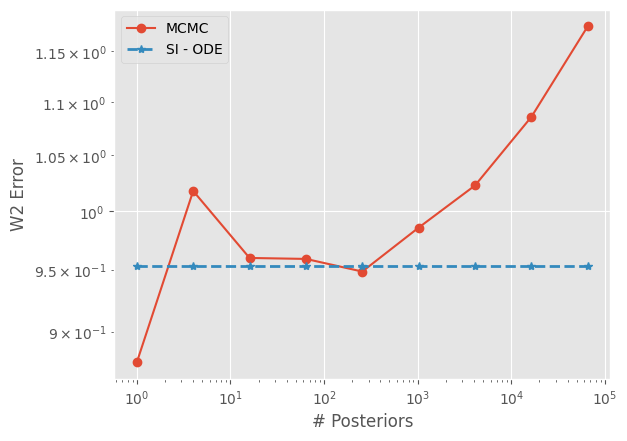

In [6]:
plt.plot(conditioning_list, wd_mcmc_means, label="MCMC", marker="o")
# plt.fill_between(conditioning_list, wd_mcmc_means - wd_mcmc_stds, wd_mcmc_means + wd_mcmc_stds, alpha=0.3)
plt.plot(conditioning_list, np.mean(wd_means) * np.ones(9), label="SI - ODE", linestyle="dashed", marker="*", linewidth=2)
# plt.plot(conditioning_list, np.mean(wd_sde_means[:3]) * np.ones(9), label="SI - SDE", linestyle="dotted")
# plt.plot(conditioning_list, np.mean(wd_ker_means) * np.ones(9), label="SI - Ker", linestyle="dashdot")
# plt.axhline(np.mean(wd_nn_array).item(), label="SI")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("# Posteriors")
plt.ylabel("W2 Error")
plt.savefig("images/budget_tanh.pdf")

In [12]:
np.mean(wd_means)

np.float64(0.9531376215815077)

In [11]:
wd_mcmc_means

array([0.87259854, 1.02256368, 0.95992997, 0.95506416, 0.95097778,
       0.99697884, 1.05535557, 1.19734663, 1.31675299])

In [18]:
nn_samps

array([[ 0.30268887,  0.30239668,  0.3028274 , ...,  0.30269235,
         0.3026039 ,  0.30272788],
       [-2.2764192 , -1.9255389 ,  0.20371702, ...,  0.93785226,
         1.579623  ,  0.75568134],
       [ 1.3349171 ,  1.3327246 ,  1.3344545 , ...,  1.3350968 ,
         1.3347311 ,  1.3326015 ],
       ...,
       [ 4.226975  , -4.091593  , -4.402232  , ..., -3.7930734 ,
        -4.6962547 , -4.570904  ],
       [ 2.1324396 ,  2.132977  ,  2.1334183 , ...,  2.133976  ,
         2.1326141 ,  2.1317716 ],
       [ 0.46376944, -0.0613534 , -0.8388279 , ..., -0.8991793 ,
         1.253093  ,  1.6073663 ]], shape=(131072, 5000), dtype=float32)

<Axes: ylabel='Density'>

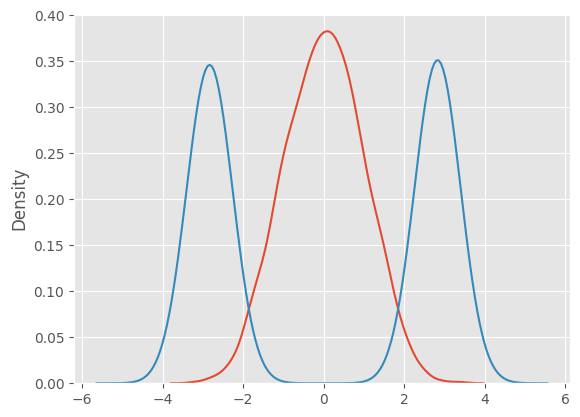

In [19]:
nn_samps = (np.load(f"nn_sde_results/ode_{0}/nn_samps.npy"))
rej_samps = np.load("rej_results/_0/rej_samps.npy")
cond_ys = np.load("rej_results/_0/conditioning_ys.npy")
kdeplot(nn_samps[1, :])
kdeplot(rej_samps[0, :])

In [6]:
nn_samps.T[:, 1::2]

array([[-2.3196094 , -0.8031901 , -1.2008958 , ...,  0.7327376 ,
         4.219262  ,  1.5540068 ],
       [-1.9666731 , -0.27429605,  0.6999517 , ..., -0.9693372 ,
        -4.110111  ,  0.19409873],
       [ 0.20216003, -0.72242856,  1.3782407 , ...,  1.3797315 ,
        -4.3665857 , -1.4586184 ],
       ...,
       [ 0.9284308 , -0.84729147, -1.4133675 , ...,  0.47190845,
        -3.7079728 , -1.646724  ],
       [ 1.5495414 , -0.7770629 , -0.39395106, ...,  1.2954367 ,
        -4.7245393 ,  3.7515223 ],
       [ 0.7506242 , -0.33681262, -1.7993442 , ...,  0.71680576,
        -4.568841  ,  4.470168  ]], shape=(5000, 65536), dtype=float32)